# Predicting house prices using California Housing data

In this notebook, I use the 'California Housing' data from scikit-learn package, to build a model that can predict the Median Value for houses in California.

- First I fetch the data and convert it into a pandas dataframe. 
- Next, I explore the input features and explore how the data is distributed. 
- I look into correlation between features and explore the need for feature engineering. 
- Finally, I try various machine learning algorithms such as Linear Regression, Decision Tree, and Ensemble model. - I finally pick the best model based on the MAPE and r2 score on the test data.

The `Histogram based Gradient Boosting Ensemble model` is final model I select. This model has an `r2_score of 0.8137221194693318` and `MAPE of 0.17118274795373187` on the test data.

### Install Python Libraries

In [74]:
# Base libraries
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing

# Utility functions 
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error

# ML Algorithms
from sklearn.cluster import KMeans
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, AdaBoostRegressor, HistGradientBoostingRegressor

# Visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

# Saving Model
import pickle

## Getting Data for California housing

In [5]:
cal_housing = fetch_california_housing(as_frame=True)

In [6]:
cal_house_df = cal_housing.frame

## Exploratory Data Analysis

In [7]:
# Getting the size of the data
print("Number of observations in the california housing data : ", cal_house_df.shape[0])

Number of observations in the california housing data :  20640


In [8]:
# Get info on the X dataset 
cal_house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [9]:
# Getting statistics for the dataset
cal_house_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Let's start by visualizing the independent variables. We can use histograms for each of the variables.

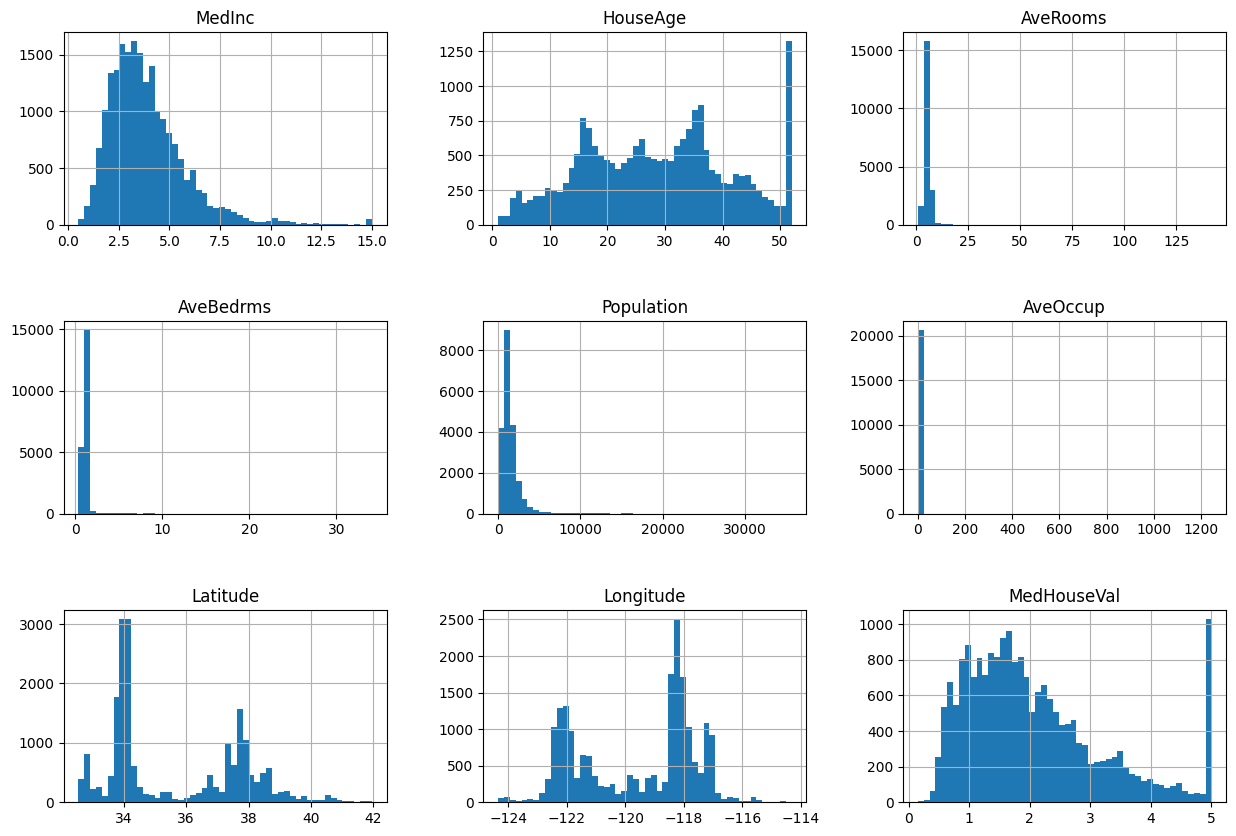

In [10]:
plt.rcParams['figure.figsize'] = (15, 10)
cal_house_df.hist(bins = 50)
plt.subplots_adjust(hspace=0.5, wspace=0.3)

Let's look at the relationship between variables next. We can use scatterplot for each input feature with the target variable. We will also create a correlation metric.

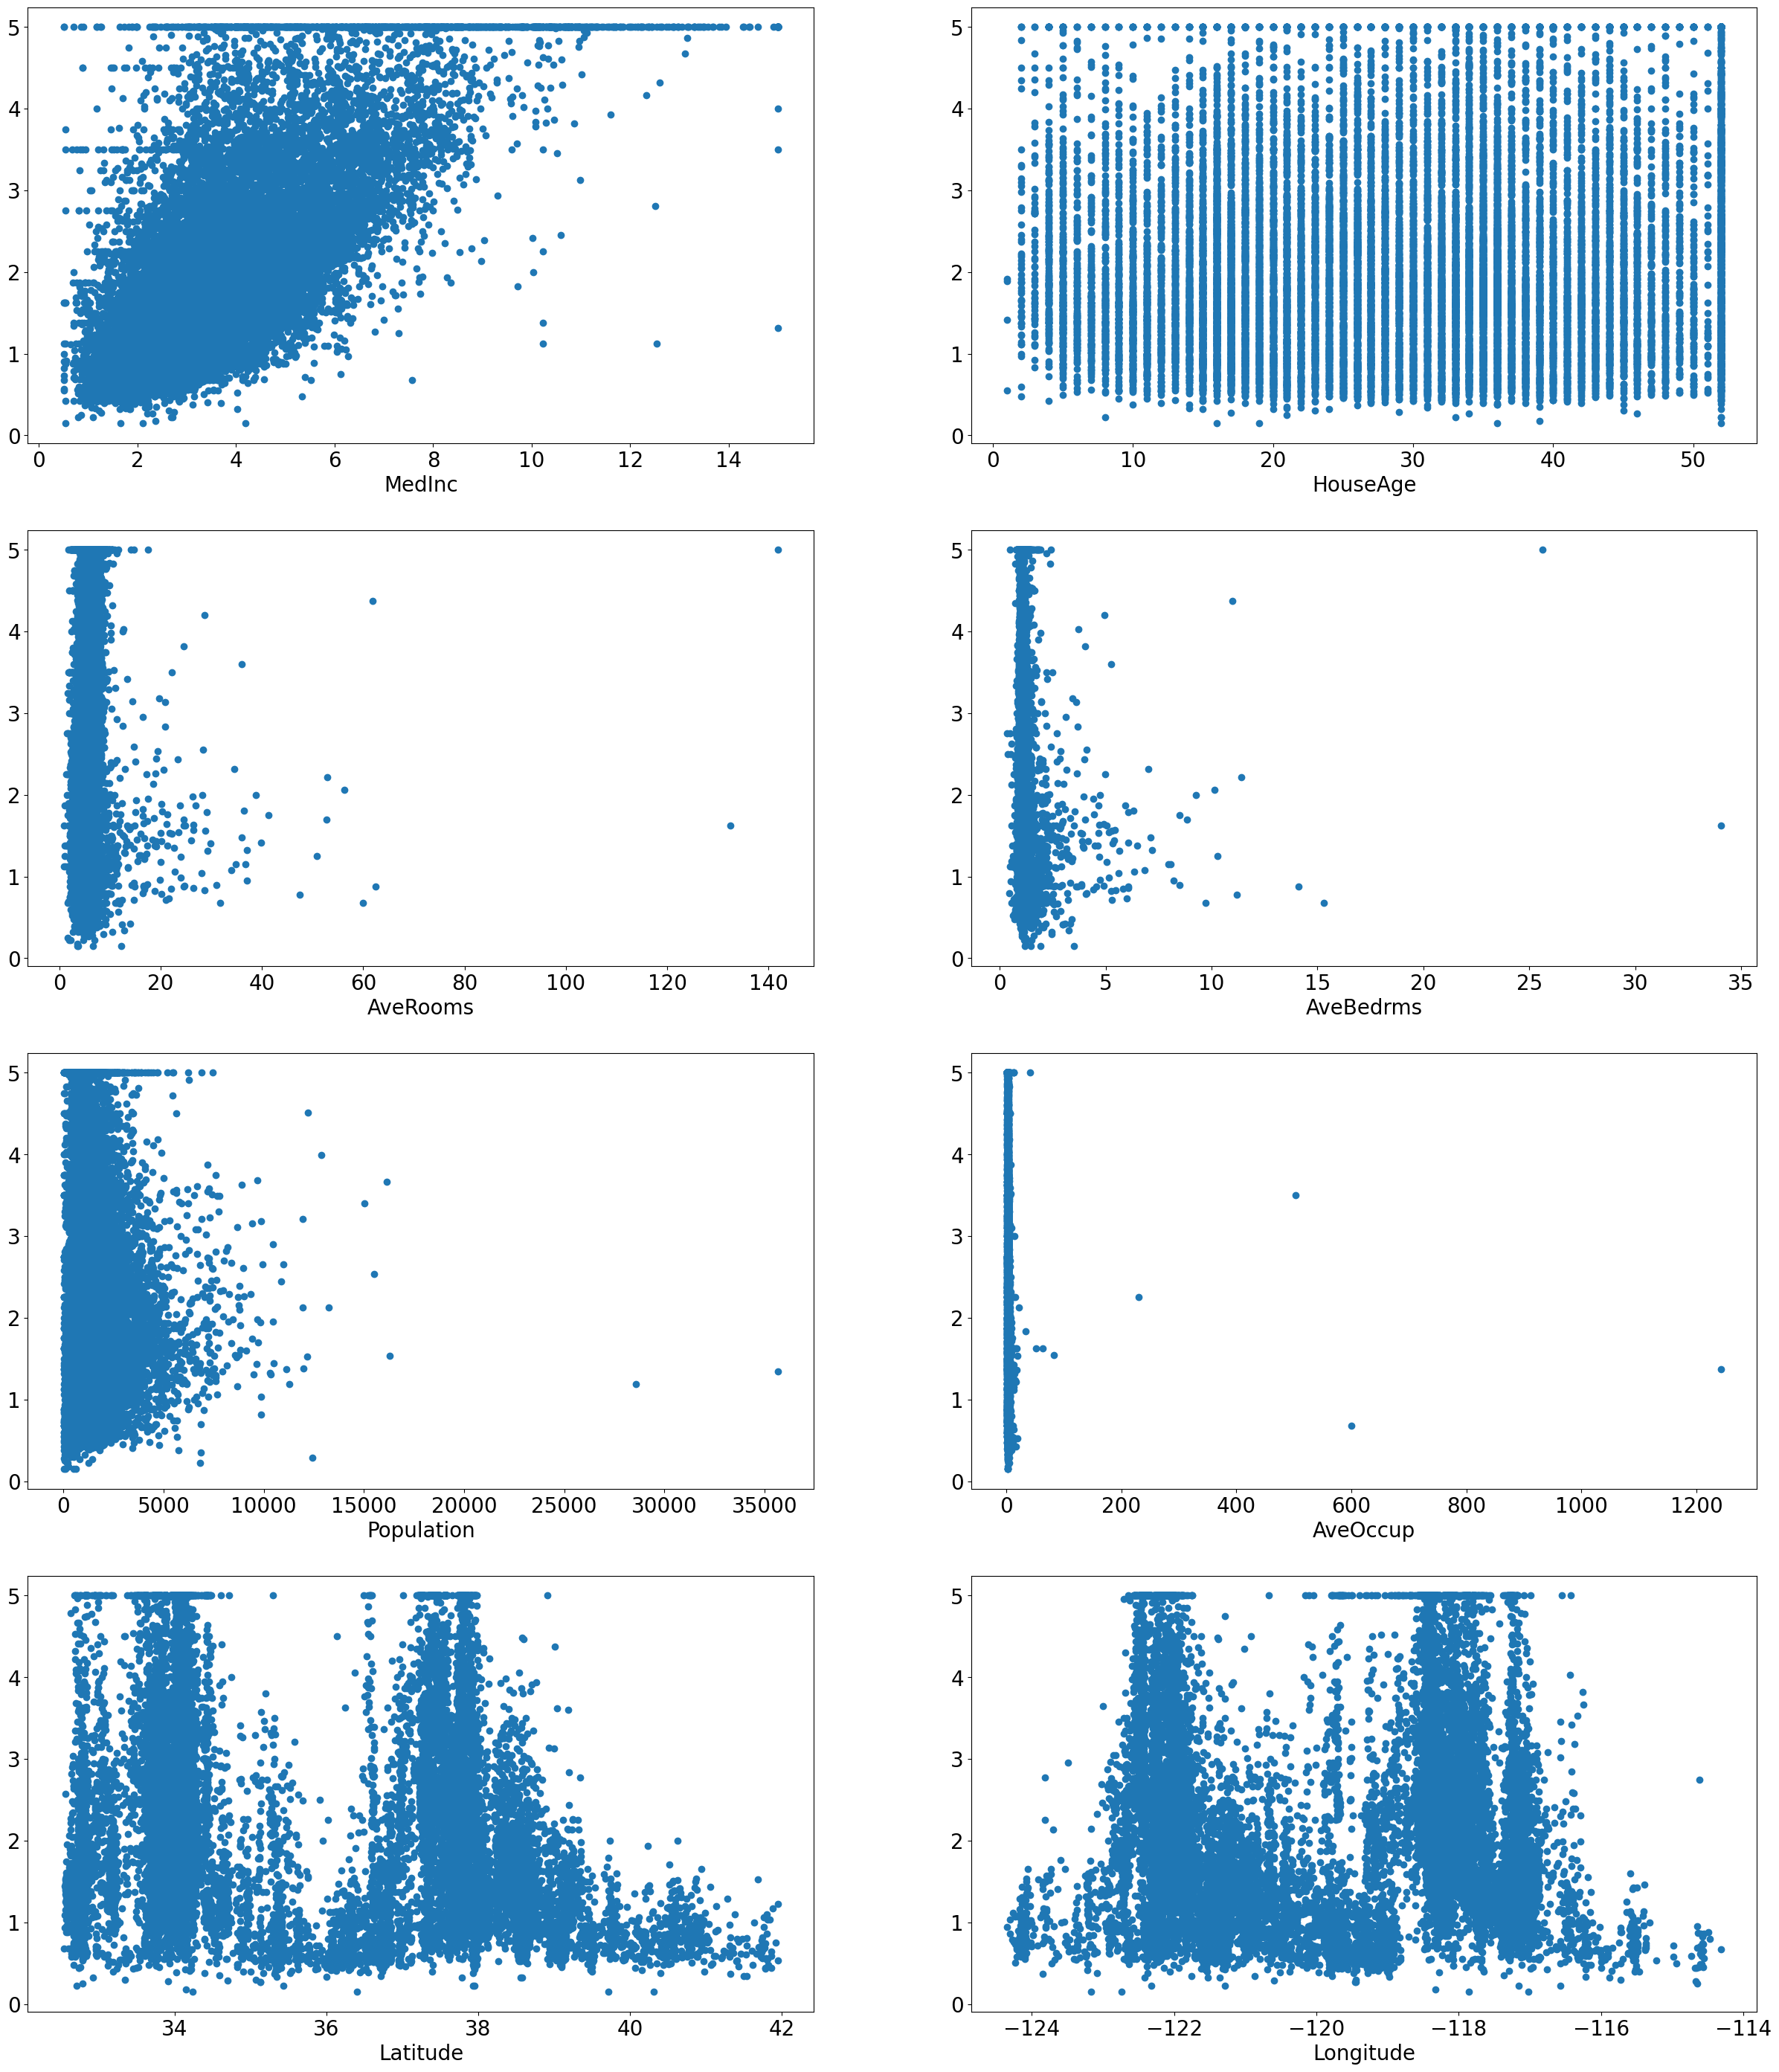

In [11]:
#sns.pairplot(cal_house_df, hue="MedHouseVal")
fig, axes = plt.subplots(4,2,figsize = (30, 35))
axes = axes.ravel()

for i in range(len(cal_housing.feature_names)):
    ax = axes[i]
    f = (cal_housing.feature_names)[i]
    df_x = cal_house_df[f]
    ax.scatter(df_x, cal_housing.target)
    ax.set_xlabel(f, fontsize=20)
    ax.tick_params(axis="both",labelsize=20)
    
plt.show()

The plots for 'AveRooms', 'AveBedrms', 'Population', and 'AveOccup' seems to be concentrated towards to the left. We will nornalize these variable and plot them again to see if they show the relationship more clearly.

In [12]:
# Scale these columns
scaler = StandardScaler()

scaled_cols = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']
cal_house_df_scaled = cal_house_df.copy()
cal_house_df_scaled[scaled_cols] = scaler.fit_transform(cal_house_df[scaled_cols])
cal_house_df_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,0.628559,-0.153758,-0.974429,-0.049597,37.88,-122.23,4.526
1,8.3014,21.0,0.327041,-0.263336,0.861439,-0.092512,37.86,-122.22,3.585
2,7.2574,52.0,1.155620,-0.049016,-0.820777,-0.025843,37.85,-122.24,3.521
3,5.6431,52.0,0.156966,-0.049833,-0.766028,-0.050329,37.85,-122.25,3.413
4,3.8462,52.0,0.344711,-0.032906,-0.759847,-0.085616,37.85,-122.25,3.422


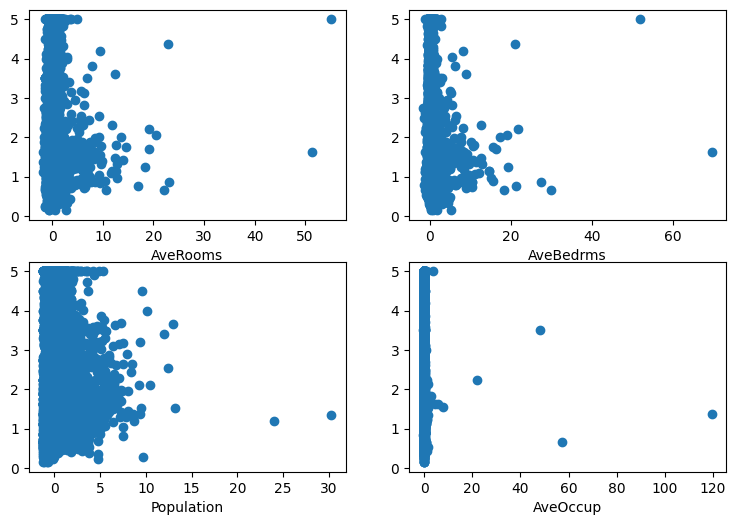

In [13]:
fig, axes = plt.subplots(2,2,figsize = (9, 6))
axes = axes.ravel()

for i in range(len(scaled_cols)):
    ax = axes[i]
    f = (scaled_cols)[i]
    df_x = cal_house_df_scaled[f]
    ax.scatter(df_x, cal_housing.target)
    ax.set_xlabel(f, fontsize=10)
    ax.tick_params(axis="both",labelsize=10)
    
plt.show()

<Axes: >

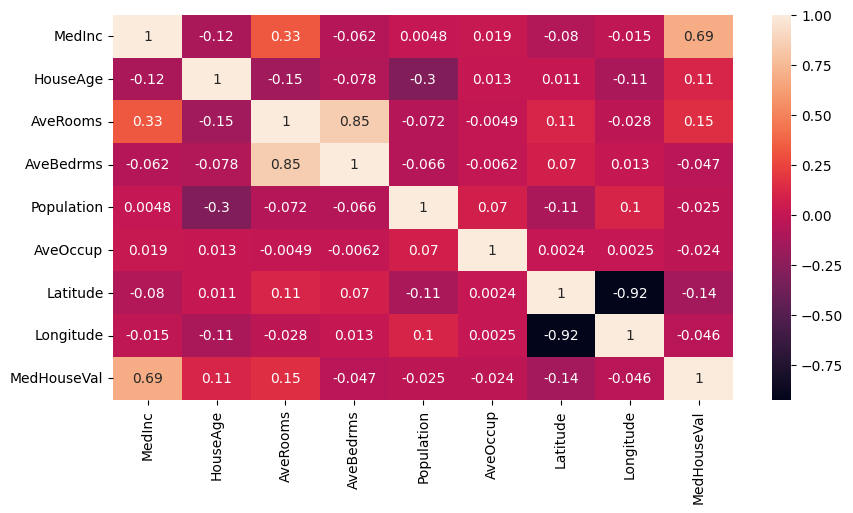

In [14]:
plt.rcParams['figure.figsize'] = (10, 5)
sns.heatmap(cal_house_df.corr(method='pearson'), annot=True)

Latitude and Longitude have very high negative correlation. Let us plot them on a map to understand if there is any relationship to house prices. The graph below shows us that house prices and population is high near the coast. 

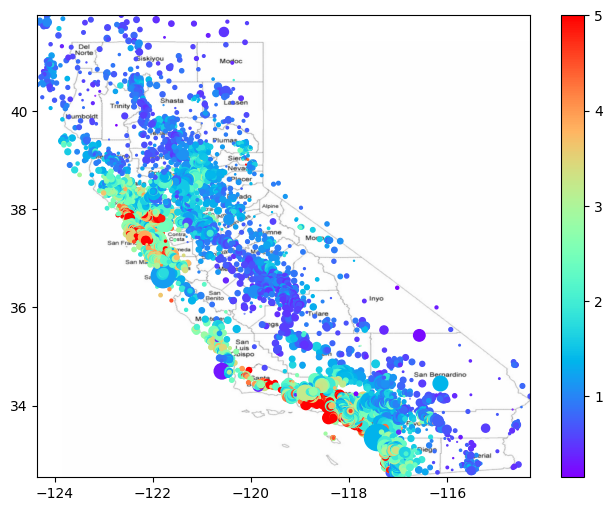

In [15]:
plt.rcParams['figure.figsize'] = (8, 6)
img = mpimg.imread('California.png')
sc = plt.scatter(cal_house_df['Longitude'], cal_house_df['Latitude'], 
            c = cal_house_df['MedHouseVal'], cmap='rainbow',
            s = cal_house_df['Population']/ 100)
            #zorder=5)
plt.colorbar(sc)
plt.imshow(img, extent=[cal_house_df['Longitude'].min(), cal_house_df['Longitude'].max(), 
                        cal_house_df['Latitude'].min(), cal_house_df['Latitude'].max()])
plt.show()

Finally, let's check if our target variable is normally distributed or not. From the data below, it doesn't look like the target variable is normally distributed.

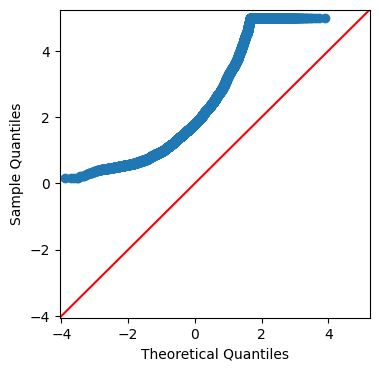

In [16]:
plt.rcParams['figure.figsize'] = (4, 4)
fig = sm.qqplot(cal_house_df['MedHouseVal'], line='45')
plt.show()

## Feature Engineering

I clustered the latitude and longitude data and used these clusters as a feature for the model. This makes sense as Latitude and Longitude together help in locating a place on the map. The clusters help me in finding what kind of location the house is located in.

I used K-means cluster for this task. I try with different values of K and pick the one based on the elbow curve. I also look at how the clusters separate the locations. I pick 4 clusters finally and create one-hot encoding columns for these location clusters.

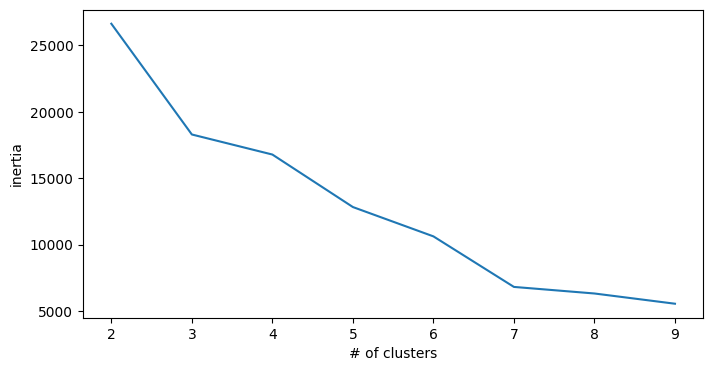

In [17]:
# Kmeans method clustering
plt.rcParams['figure.figsize'] = (8, 4)
lat_long_df = cal_house_df[['Latitude', 'Longitude']]

obj_fn = []
label_list = []
for i in range(2,10):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init="auto")
    kmeans.fit(lat_long_df)
    labels = kmeans.labels_
    label_list.append(labels)
    obj_fn.append(kmeans.inertia_)

plt.plot(list(range(2,10)), obj_fn)
plt.xlabel("# of clusters")
plt.ylabel('inertia')
plt.show()


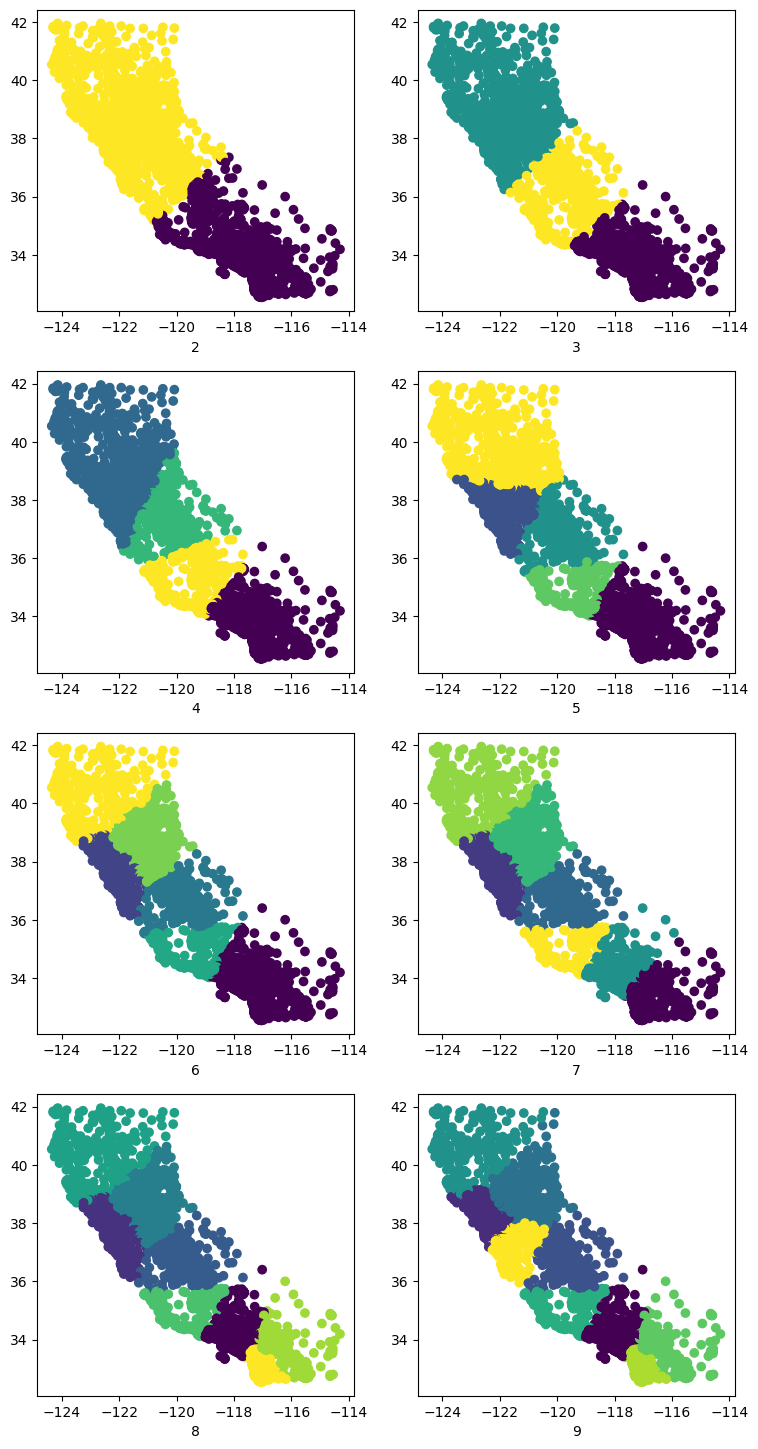

In [18]:
fig, axes = plt.subplots(4,2, figsize=(9,18))
axes = axes.ravel()

for i in range(8):
    ax = axes[i]
    ax.scatter(cal_house_df['Longitude'], cal_house_df['Latitude'], 
            c = label_list[i])
    ax.set_xlabel(i+2, fontsize=10)
    ax.tick_params(axis="both",labelsize=10)
    
plt.show()
    

In [19]:
kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto")
kmeans.fit(lat_long_df)
cal_house_df['location_cluster'] = kmeans.labels_
cal_house_df['location_cluster'] = 'location_' + cal_house_df['location_cluster'].astype(str)

In [20]:
one_hot = OneHotEncoder()
one_hot.fit(cal_house_df[['location_cluster']])

col_list = cal_house_df['location_cluster'].unique().tolist()
one_hot_df = pd.DataFrame(one_hot.transform(cal_house_df[['location_cluster']]).toarray(), columns=col_list)

cal_house_df = pd.concat([cal_house_df, one_hot_df], axis=1)

In [21]:
num_col = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']

scaler = StandardScaler()
scaler.fit(cal_house_df[num_col])

cal_house_df[num_col] = scaler.transform(cal_house_df[num_col])

## Model Training

Next, I trained some models. I started by splitting my dataset into training and test data set. I used 80% of the data as training and 20% as test data. **The models will be evaluated using the r2_score and MAPE metrics on the test data.** The final model must have MAPE below 0.2 to be acceptable.

I started with Linear Regression model and then moved on to  decision tree model. The linear regression doesn't work as well and that is expected as the target variable is not a normal distribution. I got better results with the decision tree.

### Linear Regression

In [22]:
X = cal_house_df.loc[:, ~cal_house_df.columns.isin(['MedHouseVal', 'location_cluster'])]
Y = cal_house_df.loc[:, cal_house_df.columns == 'MedHouseVal']

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=0)

In [24]:
# Lets use statsmodel as that method gives us a model summary
model = sm.OLS(Y_train, sm.add_constant(X_train)).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.620
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     2297.
Date:                Sun, 04 Feb 2024   Prob (F-statistic):               0.00
Time:                        12:13:32   Log-Likelihood:                -16705.
No. Observations:               15480   AIC:                         3.343e+04
Df Residuals:                   15468   BIC:                         3.353e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -37.0275      1.010    -36.653      0.0

So the above model shows that there is a multicollinearity problem. Let's remove the Latitude and Longitude columns. We can also eliminate one of the location dummy columns, as having all of them is not required. We also found out that 'Population' doesn't improve the adjusted-R square metric, so we can remove that.

In [25]:
train_cols = ['MedInc', 'HouseAge', 'AveOccup', 'AveBedrms', 'AveRooms',
              'location_0', 'location_1', 'location_2']

model = sm.OLS(Y_train, sm.add_constant(X_train[train_cols])).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     2412.
Date:                Sun, 04 Feb 2024   Prob (F-statistic):               0.00
Time:                        12:13:36   Log-Likelihood:                -17932.
No. Observations:               15480   AIC:                         3.588e+04
Df Residuals:                   15471   BIC:                         3.595e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0232      0.025     81.699      0.0

In [26]:
# Now we can use scikit learn method
linear_regression = LinearRegression()
linear_regression.fit(X_train[train_cols], Y_train)
linear_regression.score(X_train[train_cols], Y_train)

0.5550239856319286

In [27]:
# Predict for test set
Pred_MedValue = linear_regression.predict(X_test[train_cols])

print("The MAPE for the model is")
print(mean_absolute_percentage_error(Y_test, Pred_MedValue))

print("\nThe r2 score for the model is")
print(r2_score(Y_test, Pred_MedValue))

The MAPE for the model is
0.35447392549561163

The r2 score for the model is
0.529095713624087


### Decision Tree

In [28]:
tree_regressor = DecisionTreeRegressor(max_depth=7, random_state=0)
tree_regressor.fit(X_train, Y_train)
tree_regressor.score(X_train, Y_train)

0.7143734895348997

In [29]:
print(tree_regressor.get_params())

{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 7, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 0, 'splitter': 'best'}


In [31]:
[print(i,': ',j) for i, j in zip(tree_regressor.feature_names_in_,tree_regressor.feature_importances_)]

MedInc :  0.70537487810127
HouseAge :  0.0477330825469185
AveRooms :  0.0308758400514949
AveBedrms :  0.004763772449384599
Population :  0.008149365489039473
AveOccup :  0.13529332877246303
Latitude :  0.03309838572032547
Longitude :  0.03099273705119089
location_1 :  0.0
location_2 :  0.0
location_0 :  0.003718609817913232
location_3 :  0.0


[None, None, None, None, None, None, None, None, None, None, None, None]

In [32]:
# Predict for test set
Pred_MedValue = tree_regressor.predict(X_test)

print("The MAPE for the model is", format(mean_absolute_percentage_error(Y_test, Pred_MedValue)))
print("The r2 score for the model is", format(r2_score(Y_test, Pred_MedValue)))

The MAPE for the model is 0.29842254907095606
The r2 score for the model is 0.6476620295439477


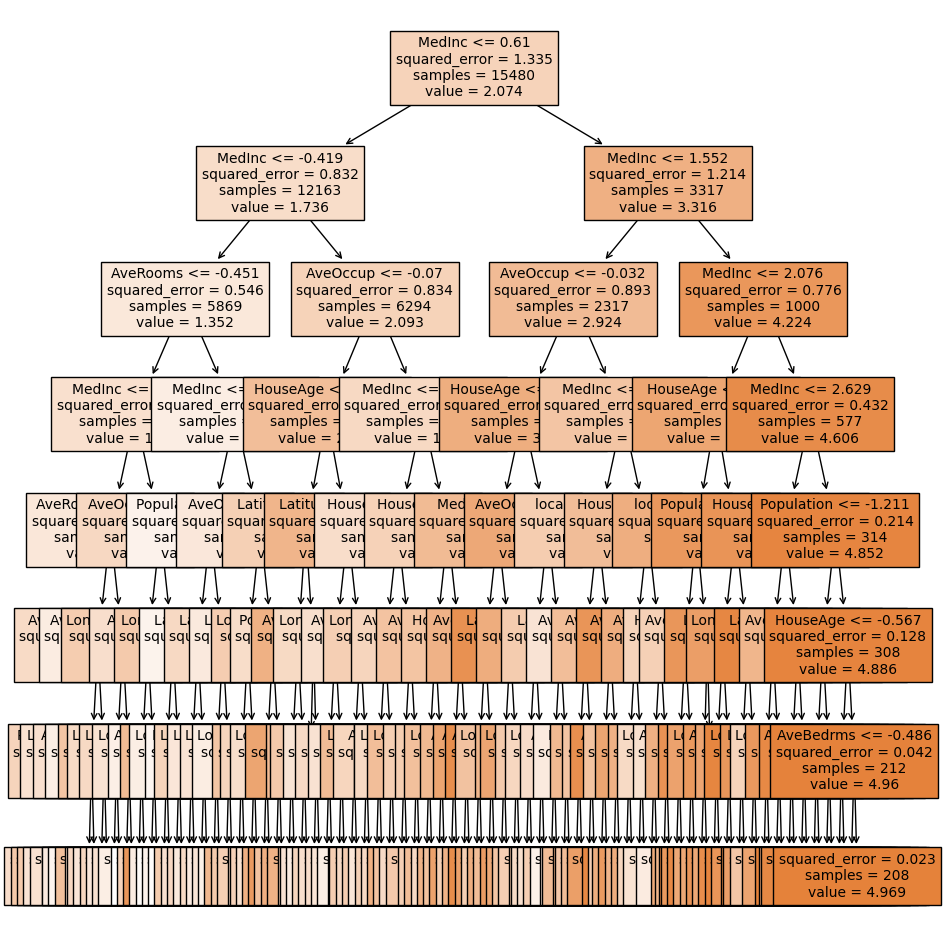

In [33]:
# Visual Plot of the tree

fig = plt.figure(figsize=(10,12))
_ =plot_tree(tree_regressor, feature_names=list(X_train.columns), filled=True, fontsize=10)

plt.show()

## Ensemble Modeling

Next, I used Ensemble modeling techniques. 
I tried Random Forest, Bagging, and Boosting. AdaBoost model did better than Bagging and Random Forest. For both Bagging and Boosting technique we used ExtraTreeRegressor from scikit-learn. ExtraTreeRegressor fits a number of randomized decision tree on various sub-samples of the dataset. Next, I tried Histogram based Gradient Boosting model. The HistGradientBoostingRegressor technique outperforms all the models.

### Random Forest

Random Forest is an Ensemble model with decision trees. It uses averaging predictions in order to reduce overfitting.

In [55]:
rf_reg = RandomForestRegressor(random_state=0)
rf_reg.fit(X_train, Y_train)
rf_reg.score(X_train, Y_train)

0.9731446609781802

In [56]:
rf_reg.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 0,
 'verbose': 0,
 'warm_start': False}

In [57]:
# Predict for test set
Pred_MedValue = rf_reg.predict(X_test)

print("The MAPE for the model is", format(mean_absolute_percentage_error(Y_test, Pred_MedValue)))
print("The r2 score for the model is", format(r2_score(Y_test, Pred_MedValue)))

The MAPE for the model is 0.19496861729502762
The r2 score for the model is 0.797557217823345


### Bagging

In [58]:
extra_tree = ExtraTreeRegressor(random_state=0)
bag_reg = BaggingRegressor(extra_tree, random_state=0)
bag_reg.fit(X_train, Y_train)
bag_reg.score(X_train, Y_train)

0.9598823126185083

In [59]:
# Predict for test set
Pred_MedValue = bag_reg.predict(X_test)

print("The MAPE for the model is", format(mean_absolute_percentage_error(Y_test, Pred_MedValue)))
print("The r2 score for the model is", format(r2_score(Y_test, Pred_MedValue)))

The MAPE for the model is 0.2033917777701789
The r2 score for the model is 0.7820203345582966


### Boosting

In [60]:
adaboost = AdaBoostRegressor(extra_tree, random_state=0)
adaboost.fit(X_train, Y_train)
adaboost.score(X_train, Y_train)

0.9994507018372513

In [61]:
adaboost.get_params()

{'estimator__ccp_alpha': 0.0,
 'estimator__criterion': 'squared_error',
 'estimator__max_depth': None,
 'estimator__max_features': 1.0,
 'estimator__max_leaf_nodes': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__random_state': 0,
 'estimator__splitter': 'random',
 'estimator': ExtraTreeRegressor(random_state=0),
 'learning_rate': 1.0,
 'loss': 'linear',
 'n_estimators': 50,
 'random_state': 0}

In [62]:
# Predict for test set
Pred_MedValue = adaboost.predict(X_test)

print("The MAPE for the model is", format(mean_absolute_percentage_error(Y_test, Pred_MedValue)))
print("The r2 score for the model is", format(r2_score(Y_test, Pred_MedValue)))

The MAPE for the model is 0.17474694266251736
The r2 score for the model is 0.8063845995274563


### HistGradientBoost Regressor

In [63]:
h_gradboost = HistGradientBoostingRegressor(random_state=0)
h_gradboost.fit(X_train, Y_train)
h_gradboost.score(X_train, Y_train)

0.8809485970603456

In [64]:
# Predict for test set
Pred_MedValue = h_gradboost.predict(X_test)

print("The MAPE for the model is", format(mean_absolute_percentage_error(Y_test, Pred_MedValue)))
print("The r2 score for the model is", format(r2_score(Y_test, Pred_MedValue)))

The MAPE for the model is 0.18341355717625585
The r2 score for the model is 0.8348055584038214


## Grid Search for parameters

Next, I performed a grid search for hyperparameters that further improves model performance. I grid search for Random Forest, AdaBoost, and HistGradientBoosting techniques. 

Lastly, I saved the best model. I used r2 score and MAPE metrics on test data to select the best model.

### RandomForestRegressor Grid Search

In [65]:
# Randomized Grid Search for hyperparameters
param_dist = {"n_estimators": [50, 100, 150],
              "max_depth": [3, 5, 7, 8, None],
              "max_features": ["sqrt", "log2", None, 1.0]}

rf_gridsearch = GridSearchCV(rf_reg, param_grid=param_dist)
rf_gridsearch.fit(X_train, Y_train)

GridSearchCV(estimator=RandomForestRegressor(random_state=0),
             param_grid={'max_depth': [3, 5, 7, 8, None],
                         'max_features': ['sqrt', 'log2', None, 1.0],
                         'n_estimators': [50, 100, 150]})

In [66]:
print(rf_gridsearch.best_score_)
print(rf_gridsearch.best_params_)

0.8209959756829035
{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 150}


In [67]:
# Predict for test set
Pred_MedValue = rf_gridsearch.predict(X_test)

print("The MAPE for the model is", format(mean_absolute_percentage_error(Y_test, Pred_MedValue)))
print("The r2 score for the model is", format(r2_score(Y_test, Pred_MedValue)))

The MAPE for the model is 0.1905442640509736
The r2 score for the model is 0.8207203796347001


### HistGradientBoostRegressor Grid Search

In [68]:
# Randomized Grid Search for hyperparameters

param_dist = {"max_depth": [3, 5, 7, 8, None],
              "l2_regularization": [0, 0.1, 0.2],
              "learning_rate": [0.1, 0.15, 0.2]}

h_gradboost_search = GridSearchCV(h_gradboost, param_grid=param_dist)
h_gradboost_search.fit(X_train, Y_train)

GridSearchCV(estimator=HistGradientBoostingRegressor(random_state=0),
             param_grid={'l2_regularization': [0, 0.1, 0.2],
                         'learning_rate': [0.1, 0.15, 0.2],
                         'max_depth': [3, 5, 7, 8, None]})

In [69]:
print(h_gradboost_search.best_score_)
print(h_gradboost_search.best_params_)

0.8333354955130471
{'l2_regularization': 0.2, 'learning_rate': 0.15, 'max_depth': None}


In [70]:
# Predict for test set
Pred_MedValue = h_gradboost_search.predict(X_test)

print("The MAPE for the model is", format(mean_absolute_percentage_error(Y_test, Pred_MedValue)))
print("The r2 score for the model is", format(r2_score(Y_test, Pred_MedValue)))

The MAPE for the model is 0.17921957597854
The r2 score for the model is 0.8376864738216145


### AdaBoostRegressor Grid Search

In [71]:
# Randomized Grid Search for hyperparameters

param_dist = {"n_estimators": [50, 100, 120, 150],
              "learning_rate": [0.01, 0.1, 0.15, 1.0]}

adaboost_search = GridSearchCV(adaboost, param_grid=param_dist)
adaboost_search.fit(X_train, Y_train)

GridSearchCV(estimator=AdaBoostRegressor(estimator=ExtraTreeRegressor(random_state=0),
                                         random_state=0),
             param_grid={'learning_rate': [0.01, 0.1, 0.15, 1.0],
                         'n_estimators': [50, 100, 120, 150]})

In [72]:
print(adaboost_search.best_score_)
print(adaboost_search.best_params_)

0.8164847952758535
{'learning_rate': 1.0, 'n_estimators': 150}


In [73]:
# Predict for test set
Pred_MedValue = adaboost_search.predict(X_test)

print("The MAPE for the model is", format(mean_absolute_percentage_error(Y_test, Pred_MedValue)))
print("The r2 score for the model is", format(r2_score(Y_test, Pred_MedValue)))

The MAPE for the model is 0.17118274795373187
The r2 score for the model is 0.8137221194693318


### Saving the model

In [76]:
filename = 'california_housing_price_prediction_model.sav'
pickle.dump(h_gradboost_search, open(filename, 'wb')) 